In [10]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import re
import json
import random
from collections import defaultdict
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import sys
import numpy as np

# ------------------ 라이브러리 버전 출력 ------------------
def print_library_versions():
    print(f"🐍 Python version: {sys.version}\n")
    print("📦 External Library Versions:")
    try:
        import numpy as np
        print("numpy:", np.__version__)
    except:
        print("numpy: Not found")
    try:
        import pandas as pd
        print("pandas:", pd.__version__)
    except:
        print("pandas: Not found")

    try:
        import matplotlib
        print("matplotlib:", matplotlib.__version__)
    except:
        print("matplotlib: Not found")

    try:
        import sentence_transformers
        print("sentence-transformers:", sentence_transformers.__version__)
    except:
        print("sentence-transformers: Not found")

    try:
        import sklearn
        print("scikit-learn:", sklearn.__version__)
    except:
        print("scikit-learn: Not found")

    try:
        import xgboost
        print("xgboost:", xgboost.__version__)
    except:
        print("xgboost: Not found")

    try:
        import joblib
        print("joblib:", joblib.__version__)
    except:
        print("joblib: Not found")

print_library_versions()
# ----------------------------------------------------------


🐍 Python version: 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]

📦 External Library Versions:
numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
sentence-transformers: 4.1.0
scikit-learn: 1.6.1
xgboost: 2.1.4
joblib: 1.5.0


In [12]:
# --- Seed 고정 ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [13]:
## 함수 선언
# --- JSONL 로딩 ---
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            caption = record.get("caption", "")
            rate = float(record.get("rate", 0.0))
            data.append({"text": caption, "rate": rate})
    return pd.DataFrame(data)


# --- 텍스트 전처리 ---
def preprocess_text(text):
    text = re.sub(r'[^가-힣\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# --- Oversampling 함수 ---
def apply_oversampling(df, num_bins=5):
    rate_buckets = defaultdict(list)

    # 균등하게 분할할 수 있도록 rate를 버킷으로 나눔
    min_rate, max_rate = df['rate'].min(), df['rate'].max()
    bin_size = (max_rate - min_rate) / num_bins

    def bucket_idx(rate):
        return int((rate - min_rate) // bin_size)

    for _, row in df.iterrows():
        idx = bucket_idx(row['rate'])
        rate_buckets[idx].append(row)

    # Oversampling
    max_count = max(len(samples) for samples in rate_buckets.values())
    balanced_samples = []

    for samples in rate_buckets.values():
        if len(samples) < max_count:
            oversampled = random.choices(samples, k=max_count - len(samples))
            balanced_samples.extend(samples + oversampled)
        else:
            balanced_samples.extend(samples)

    random.shuffle(balanced_samples)
    return pd.DataFrame(balanced_samples)


In [14]:
# --- 데이터 로딩 및 전처리 ---
df = load_jsonl("./data/RM_data/caption/train/gpt_output_with_human_rate_train.jsonl")
df['cleaned_text'] = df['text'].apply(preprocess_text)

# --- Train/Test 분할) ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# --- Oversampling은 train set에만 적용 ---
train_df_balanced = apply_oversampling(train_df)

# --- BERT 임베딩 ---
bert_model = SentenceTransformer('distiluse-base-multilingual-cased-v2')  # 한국어 포함 멀티링구얼

X_train = bert_model.encode(train_df_balanced['cleaned_text'].tolist(), show_progress_bar=True)
y_train = train_df_balanced['rate'].values

X_test = bert_model.encode(test_df['cleaned_text'].tolist(), show_progress_bar=True)
y_test = test_df['rate'].values

# --- 모델 리스트 정의 ---
models = {
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "XGBRegressor": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
}

# --- 모델 학습 및 평가 ---
best_model_name = None
best_model = None
best_r2 = float('-inf')  # 초기값을 -무한대로 설정

for name, model in models.items():
    print(f"\n🔧 모델: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"📉 MSE: {mse:.6f}")
    print(f"📈 MAE: {mae:.6f}")
    print(f"🔍 R² Score: {r2:.6f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_model_name = name

# --- 가장 성능이 좋은 모델 저장 ---
if best_model:
    save_path = f"best_model_{best_model_name}.pkl"
    joblib.dump(best_model, save_path)
    print(f"\n💾 가장 성능이 좋은 모델 '{best_model_name}' 저장 완료: {save_path}")


Batches: 100%|██████████| 3/3 [00:07<00:00,  2.65s/it]



🔧 모델: GradientBoostingRegressor
📉 MSE: 0.256948
📈 MAE: 0.423360
🔍 R² Score: 0.146668

🔧 모델: XGBRegressor
📉 MSE: 0.244830
📈 MAE: 0.412166
🔍 R² Score: 0.186912

🔧 모델: RandomForestRegressor
📉 MSE: 0.228833
📈 MAE: 0.400256
🔍 R² Score: 0.240037

💾 가장 성능이 좋은 모델 'RandomForestRegressor' 저장 완료: best_model_RandomForestRegressor.pkl


C:\Users\taeho\AppData\Local\Temp\ipykernel_12896\108304903.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\taeho\anaconda3\envs\rl_\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


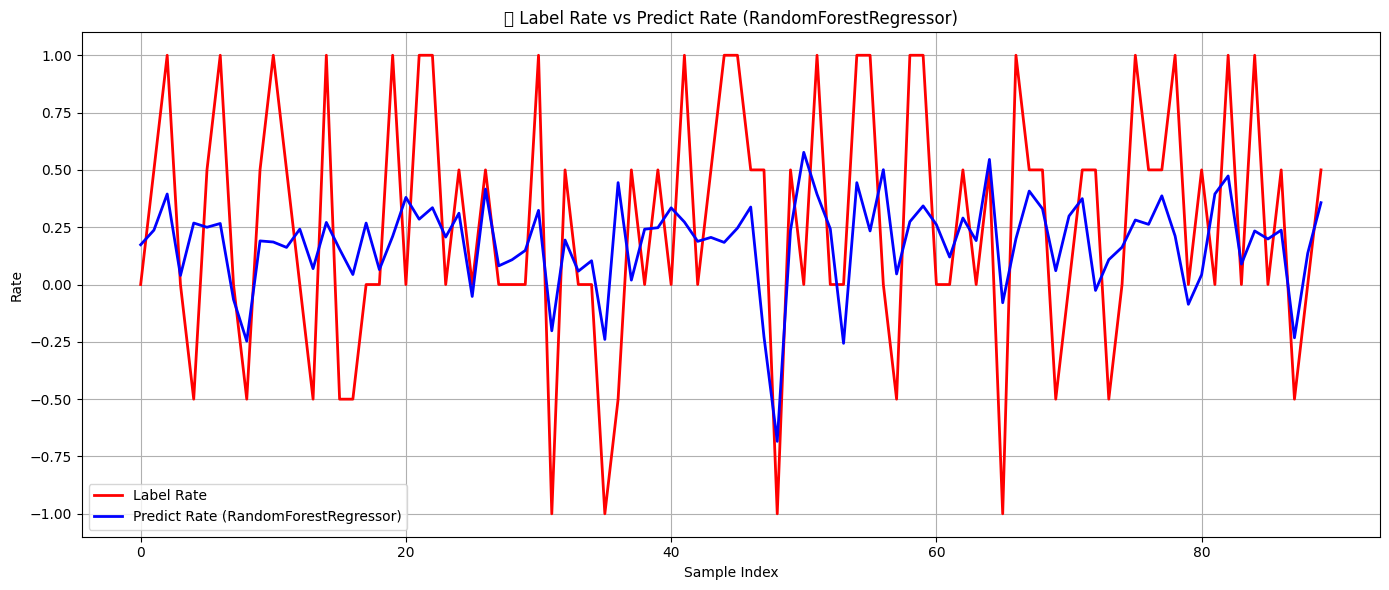

In [15]:
# --- best_model로 예측 ---
best_preds = best_model.predict(X_test)

# --- 시각화 ---
x = list(range(len(y_test)))

plt.figure(figsize=(14, 6))

# 실제 rate (빨간 선)
plt.plot(x, y_test, label='Label Rate', color='red', linewidth=2)

# best_model 예측 rate (파란 선)
plt.plot(x, best_preds, label=f'Predict Rate ({best_model_name})', color='blue', linewidth=2)

plt.xlabel("Sample Index")
plt.ylabel("Rate")
plt.title(f"📈 Label Rate vs Predict Rate ({best_model_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Batches: 100%|██████████| 2/2 [00:03<00:00,  1.90s/it]


✅ Best Model Test MSE: 0.2711
✅ Best Model Test MAE: 0.4126


C:\Users\taeho\AppData\Local\Temp\ipykernel_12896\2390445541.py:55: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\taeho\anaconda3\envs\rl_\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


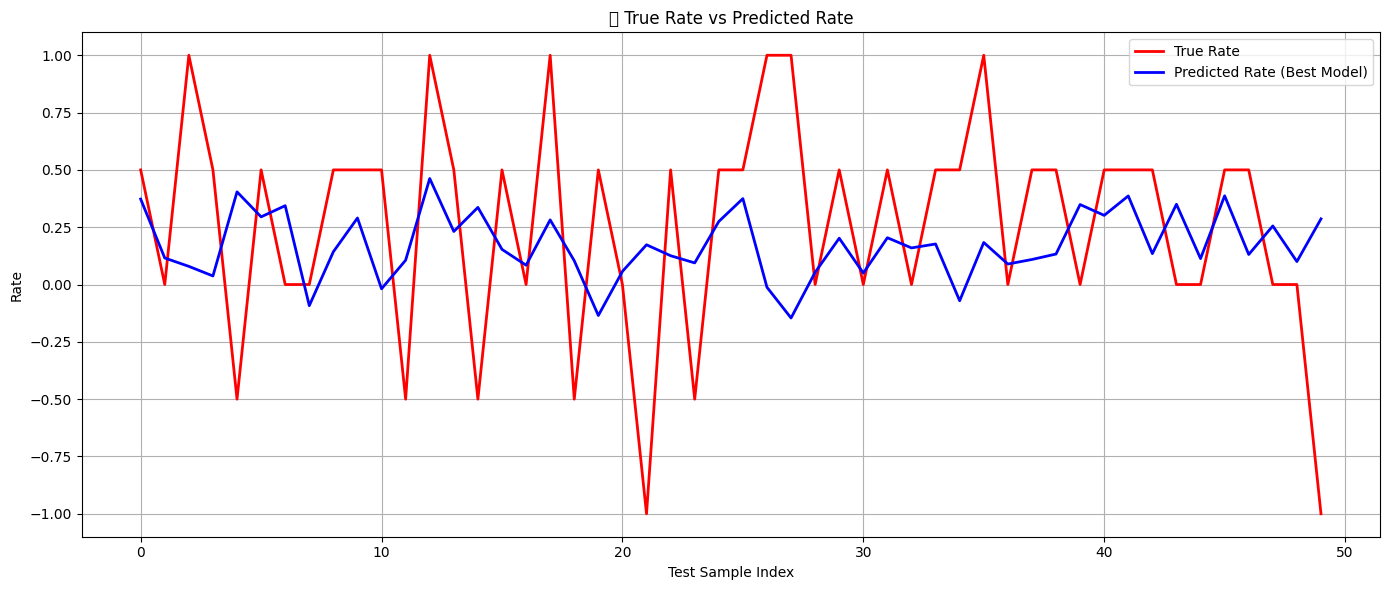

In [16]:
#### 테스트하는 코드 ###

# 1. 데이터 로딩
def load_test_data(jsonl_path):
    captions = []
    rates = []
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            captions.append(record["caption"])
            rates.append(float(record["rate"]))
    return captions, np.array(rates)

# 2. 텍스트 전처리 함수
def preprocess_text(text):
    text = re.sub(r'[^가-힣\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- 불러올 테스트 JSONL 파일 경로 ---
test_path = "./data/RM_data/caption/test/gpt_output_with_human_rate_test.jsonl"

# 3. 텍스트 및 레이블 불러오기
captions, y_test = load_test_data(test_path)
cleaned_captions = [preprocess_text(text) for text in captions]

# 4. 임베딩
bert_model = SentenceTransformer('distiluse-base-multilingual-cased-v2')
X_test = bert_model.encode(cleaned_captions, show_progress_bar=True)

# 5. best_model 로딩
model_path = f"best_model_{best_model_name}.pkl"
best_model = joblib.load(model_path)
# 6. 예측
preds = best_model.predict(X_test)

# 7. 손실 지표 출력
mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"✅ Best Model Test MSE: {mse:.4f}")
print(f"✅ Best Model Test MAE: {mae:.4f}")

# 8. 시각화
x = list(range(len(y_test)))

plt.figure(figsize=(14, 6))
plt.plot(x, y_test, label='True Rate', color='red', linewidth=2)
plt.plot(x, preds, label='Predicted Rate (Best Model)', color='blue', linewidth=2)
plt.xlabel("Test Sample Index")
plt.ylabel("Rate")
plt.title("📊 True Rate vs Predicted Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
